# Agrupamento Hierárquico

***

Agrupamento hierárquico é uma alternativa que não requer
uma escolha pré-definida de K, e que provê uma saída
determinística (sem aleatoriedade)

In [25]:
!pip install ucimlrepo

In [26]:
# Bibliotecas de manipualção e visualização de dados
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions

# Classes do modelo
from sklearn.cluster import AgglomerativeClustering

from scipy.cluster.hierarchy import dendrogram
import collections

import warnings
warnings.filterwarnings('ignore')

## Conjunto de dados

In [27]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
iris = fetch_ucirepo(id=53)

# data (as pandas dataframes)
X = iris.data.features
y = iris.data.targets

dataset = pd.concat([X,y], axis=1)
dataset

,sepal length,sepal width,petal length,petal width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [28]:
# Vamos utilizar apenas duas features para facilitar a visualização
feature_0 = "petal length"
feature_1 = "petal width"

X = dataset.iloc[:,[2,3]]

## [Agglomerative Clustering](https://scikit-learn.org/stable/modules/clustering.html#hierarchical-clustering)

Mescla recursivamente pares de clusters de dados de amostra; usa a distância de linkage (A dissimilaridade entre dois grupos).

Alguns parâmetros podem ser ajustados:

 - `n_clusters`: Número de agrupamentos. Pode receber um valor inteiro ou None.
 - `metric`: Métrica usada para calcular o linkage: 'euclidean', 'l1', 'l2', 'manhattan', 'cosine', ou 'precomputed'. Se 'n_clusters" for None a distância Euclideana será usada.
 - `linkage`: Tipo de linkage usado: ‘ward’, ‘complete’, ‘average’, ‘single’

A [documentação](https://scikit-learn.org/stable/modules/clustering.html#hierarchical-clustering) possui a descrição dos demais parâmetros.

In [29]:
# model = AgglomerativeClustering(n_clusters=3)
model = AgglomerativeClustering(n_clusters=None, distance_threshold=2.5)
# Se você não especificar o número de clusters (n_clusters=None), o algoritmo não saberá quando parar de aglomerar os clusters.
model.fit(X)
labels = model.labels_
labels

array([3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 4, 4, 1, 2, 4, 4, 4, 2, 4, 2, 2, 4, 2, 4, 2, 4,
       4, 2, 4, 2, 1, 2, 1, 4, 4, 4, 4, 1, 4, 2, 2, 2, 2, 1, 4, 4, 4, 4,
       2, 2, 4, 4, 2, 2, 4, 4, 4, 4, 2, 2, 0, 1, 0, 0, 0, 0, 4, 0, 0, 0,
       1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1])

In [30]:
model.get_params()

{'compute_distances': False,
 'compute_full_tree': 'auto',
 'connectivity': None,
 'distance_threshold': 2.5,
 'linkage': 'ward',
 'memory': None,
 'metric': 'euclidean',
 'n_clusters': None}

In [31]:
collections.Counter(labels)

Counter({np.int64(3): 50,
         np.int64(4): 27,
         np.int64(1): 26,
         np.int64(2): 19,
         np.int64(0): 28})

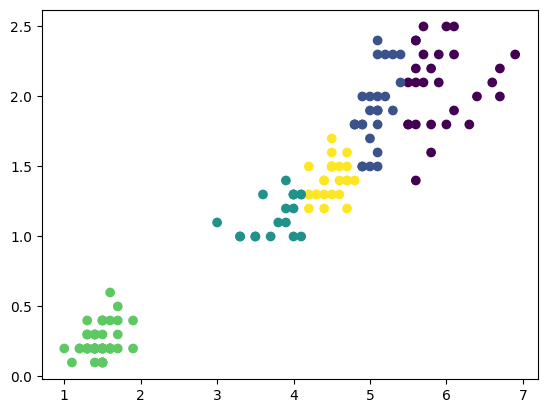

In [32]:
plt.scatter(X[feature_0], X[feature_1], c=labels)
plt.show()

## Para visualizar os resultados, pode-se usar um **dendograma**

Segue o link para documentação [link](https://scikit-learn.org/stable/auto_examples/cluster/plot_agglomerative_dendrogram.html).



In [33]:
# Método para visualização
def plot_dendrogram(model, **kwargs):
    # Primeiramente vamos criar a linkage matriz e então plotar o dendograma

    # criando a contagem the exemplos abaixo de cada nó
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # nó da folha
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot o dendograma correspondente
    dendrogram(linkage_matrix, **kwargs)

**o eixo y do dendograma é (proporcional) a distância entre os grupos que foram combinados**

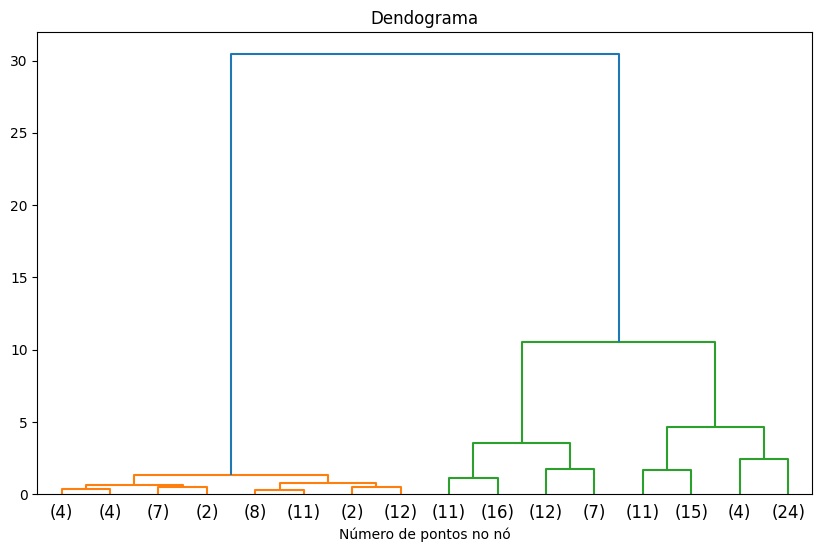

In [34]:
# Alguns parâmetros precisam receber determinados valores para mostrar a árvore completa
model = AgglomerativeClustering(n_clusters=None,distance_threshold=0, compute_full_tree=True)
# n_clusters=None agrupa as instâncias até que reste apenas um único cluster
# ou até que o distance_threshold seja atingido.
# distance_threshold=0 - continua a aglomeração até que todos os pontos sejam agrupados em um único cluster

model = model.fit(X)
plt.figure(figsize=(10, 6))
plt.title("Dendograma")

# Plotando o top 3 níveis do dendograma
plot_dendrogram(model, truncate_mode="level", p=3)
plt.xlabel("Número de pontos no nó")
#plt.axhline(y=10, color='red')
plt.show()